# 🧑‍⚖️ Phase 7-3: A/B 테스트와 Human Evaluation
> "모든 평가 메트릭은 사람의 판단을 근사하려는 시도다. 근사가 충분한지는, 결국 사람이 판단해야 한다."

## 학습 목표
1. 자동 메트릭의 근본적 한계를 이해한다
2. Absolute Scoring (1-5 Likert)을 구현한다
3. Pairwise Comparison + Position Bias 교정을 구현한다
4. Best-of-N 평가를 구현한다
5. Cohen's Kappa로 평가자 간 일치도를 측정한다
6. 3단계 평가 피라미드를 완성한다

In [ ]:
# !pip install numpy matplotlib scipy -q

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
from datetime import datetime
import json
import random

random.seed(42)
np.random.seed(42)

print(f"📅 실행 시각: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("🧑‍⚖️ Human Evaluation 프레임워크 준비 완료")

📅 실행 시각: 2026-03-16 16:55
🧑‍⚖️ Human Evaluation 프레임워크 준비 완료


## 1. 자동 메트릭의 한계

### BLEU가 높아도 틀릴 수 있는 사례

| BLEU | 예측 SQL | 문제점 |
|:----:|----------|--------|
| 0.85 | `SELECT name FROM employees WHERE salary > 50000` | 원래 `>=` 인데 `>` → 경계값 오류 |
| 0.90 | `SELECT name, department FROM employees` | `salary` 빠짐 → 핵심 컴럼 누락 |
| 0.75 | 정확한 SQL이지만 alias 다름 | 기능적으로 완벽하지만 낮은 점수 |

### 자동 메트릭이 놓치는 것
1. **의미적 정확성**: 문법은 맞지만 논리가 틀림
2. **사용자 의도**: "최근 직원"이 최근 입사인지 최근 활동인지
3. **실용성**: SQL은 맞지만 실행 시간이 비현실적
4. **안전성**: SQL injection 가능한 패턴

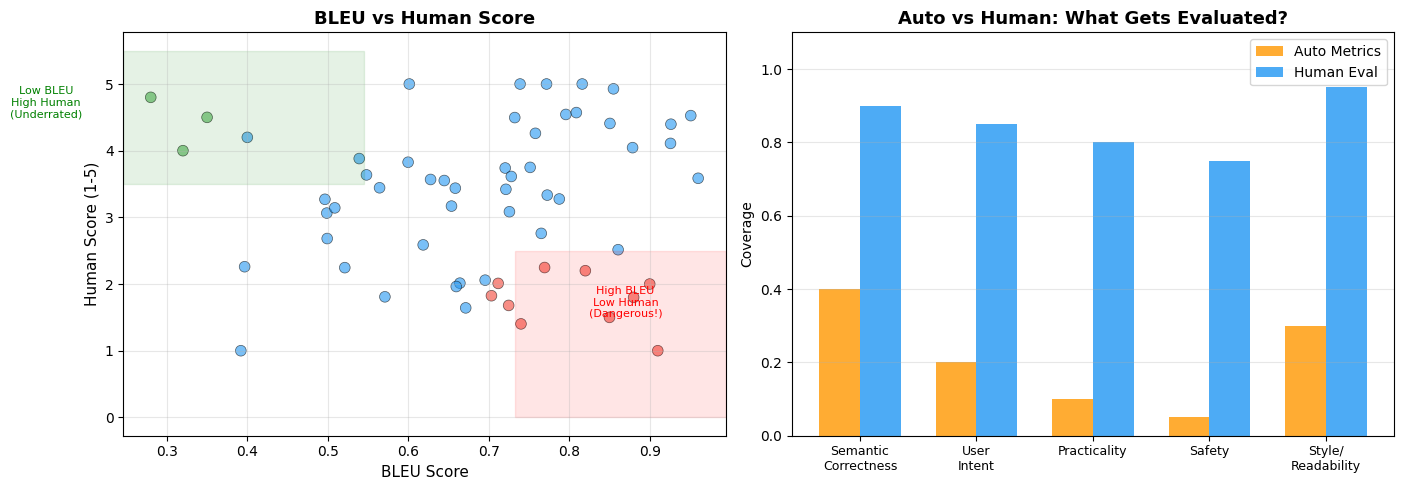

💡 빨간 점: BLEU는 높지만 사람 평가는 낮은 '위험한' 케이스
   녹색 점: BLEU는 낮지만 사람 평가는 높은 '과소평가' 케이스


In [2]:
# 자동 메트릭의 한계 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: BLEU vs Human Score scatter
np.random.seed(42)
n_points = 50
bleu_scores = np.random.beta(5, 2, n_points)
# Human scores: loosely correlated with BLEU but with significant noise
human_scores = np.clip(bleu_scores * 3 + np.random.normal(0, 1.2, n_points) + 1, 1, 5)
# Add some adversarial examples (high BLEU, low human)
bleu_scores = np.append(bleu_scores, [0.85, 0.90, 0.88, 0.82, 0.91])
human_scores = np.append(human_scores, [1.5, 2.0, 1.8, 2.2, 1.0])
# Add some (low BLEU, high human)
bleu_scores = np.append(bleu_scores, [0.35, 0.28, 0.40, 0.32])
human_scores = np.append(human_scores, [4.5, 4.8, 4.2, 4.0])

colors = ['#F44336' if (b > 0.7 and h < 2.5) else '#4CAF50' if (b < 0.4 and h > 3.5) else '#2196F3' 
          for b, h in zip(bleu_scores, human_scores)]

axes[0].scatter(bleu_scores, human_scores, c=colors, alpha=0.6, edgecolors='black', linewidth=0.5, s=60)
axes[0].set_xlabel('BLEU Score', fontsize=11)
axes[0].set_ylabel('Human Score (1-5)', fontsize=11)
axes[0].set_title('BLEU vs Human Score', fontsize=13, fontweight='bold')

# Highlight regions
axes[0].axhspan(0, 2.5, xmin=0.65, xmax=1.0, alpha=0.1, color='red')
axes[0].text(0.87, 1.5, 'High BLEU\nLow Human\n(Dangerous!)', ha='center', fontsize=8, color='red')
axes[0].axhspan(3.5, 5.5, xmin=0, xmax=0.4, alpha=0.1, color='green')
axes[0].text(0.15, 4.5, 'Low BLEU\nHigh Human\n(Underrated)', ha='center', fontsize=8, color='green')
axes[0].grid(True, alpha=0.3)

# Panel 2: What auto metrics miss
categories = ['Semantic\nCorrectness', 'User\nIntent', 'Practicality', 'Safety', 'Style/\nReadability']
auto_coverage = [0.4, 0.2, 0.1, 0.05, 0.3]
human_coverage = [0.9, 0.85, 0.8, 0.75, 0.95]

x = np.arange(len(categories))
width = 0.35
axes[1].bar(x - width/2, auto_coverage, width, label='Auto Metrics', color='#FF9800', alpha=0.8)
axes[1].bar(x + width/2, human_coverage, width, label='Human Eval', color='#2196F3', alpha=0.8)
axes[1].set_ylabel('Coverage')
axes[1].set_title('Auto vs Human: What Gets Evaluated?', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, fontsize=9)
axes[1].legend()
axes[1].set_ylim(0, 1.1)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print("💡 빨간 점: BLEU는 높지만 사람 평가는 낮은 '위험한' 케이스")
print("   녹색 점: BLEU는 낮지만 사람 평가는 높은 '과소평가' 케이스")

## 2. Absolute Scoring (1-5 Likert Scale)

### 평가 루브릭 (Rubric)
| 점수 | 등급 | 기준 |
|:----:|------|------|
| 5 | Excellent | 완벽하게 정확하고, 효율적이며, 가독성 높음 |
| 4 | Good | 정확하지만 사소한 개선 여지 있음 (별칭, 정렬 등) |
| 3 | Acceptable | 대부분 맞지만 일부 오류 있음 (결과에 영향) |
| 2 | Poor | 의도는 맞지만 중요한 오류 있음 |
| 1 | Fail | 완전히 틀리거나 실행 불가 |

### 핵심: 루브릭 없는 평가는 의미 없다
- 명확한 기준 없이 "1-5점을 매겨주세요"는 평가자마다 기준이 달라짐
- 루브릭이 구체적일수록 평가 일관성(Cohen's Kappa) 향상

In [4]:
# ============================================================
# Absolute Scoring 프레임워크
# ============================================================

class AbsoluteScorer:
    """1-5 Likert Scale 평가 프레임워크"""
    
    RUBRIC = {
        5: "Excellent - 완벽하게 정확, 효율적, 가독성 높음",
        4: "Good - 정확하지만 사소한 개선 여지 (별칭, 정렬 등)",
        3: "Acceptable - 대부분 맞지만 일부 오류 (결과에 영향)",
        2: "Poor - 의도는 맞지만 중요한 오류",
        1: "Fail - 완전히 틀리거나 실행 불가",
    }
    
    def __init__(self):
        self.evaluations = []
    
    def display_task(self, question: str, prediction: str, reference: str = None, 
                     task_id: int = 0):
        """\ud3c9\uac00 \ud0dc\uc2a4\ud06c \ucd9c\ub825"""
        print(f"\n{'='*60}")
        print(f"📋 Task #{task_id}")
        print(f"{'='*60}")
        print(f"질문: {question}")
        print(f"모델 출력: {prediction}")
        if reference:
            print(f"참고 정답: {reference}")
        print(f"\n📏 평가 기준:")
        for score, desc in sorted(self.RUBRIC.items(), reverse=True):
            print(f"   {score}: {desc}")
    
    def record_score(self, task_id: int, score: int, reason: str = ""):
        """\uc810\uc218 \uae30\ub85d"""
        assert 1 <= score <= 5, "Score must be between 1 and 5"
        self.evaluations.append({
            'task_id': task_id,
            'score': score,
            'reason': reason,
        })
    
    def get_statistics(self) -> Dict:
        """\ud1b5\uacc4 \uacc4\uc0b0"""
        if not self.evaluations:
            return {}
        scores = [e['score'] for e in self.evaluations]
        return {
            'count': len(scores),
            'mean': np.mean(scores),
            'std': np.std(scores),
            'median': np.median(scores),
            'distribution': {s: scores.count(s) for s in range(1, 6)},
        }


# 시뮬레이션 (실제로는 사람이 평가)
scorer = AbsoluteScorer()

# 시뮬레이션용 평가 태스크
eval_tasks = [
    {
        'question': '직원 테이블에서 모든 직원의 이름을 조회해줘',
        'prediction': 'SELECT name FROM employees',
        'reference': 'SELECT name FROM employees',
        'sim_score': 5, 'sim_reason': '완벽 일치'
    },
    {
        'question': '부서별 평균 급여를 알려줘',
        'prediction': 'SELECT department, AVG(salary) FROM employees GROUP BY department',
        'reference': 'SELECT department, AVG(salary) as avg_salary FROM employees GROUP BY department',
        'sim_score': 4, 'sim_reason': 'alias 없지만 기능적으로 동일'
    },
    {
        'question': '급여가 50000 이상인 직원을 조회해줘',
        'prediction': 'SELECT * FROM employees WHERE salary > 50000',
        'reference': 'SELECT * FROM employees WHERE salary >= 50000',
        'sim_score': 3, 'sim_reason': '>= 대신 > 사용, 경계값 오류'
    },
    {
        'question': '부서별 직원 수를 알려줘',
        'prediction': 'SELECT department FROM employees',
        'reference': 'SELECT department, COUNT(*) FROM employees GROUP BY department',
        'sim_score': 2, 'sim_reason': 'COUNT와 GROUP BY 누락'
    },
    {
        'question': '프로젝트별 배정된 직원 이름을 알려줘',
        'prediction': 'SELECT * FROM departments',
        'reference': 'SELECT p.name, e.name FROM projects p JOIN assignments a ON p.id = a.project_id JOIN employees e ON a.employee_id = e.id',
        'sim_score': 1, 'sim_reason': '완전히 다른 테이블 조회'
    },
]

# 평가 시뮬레이션
for i, task in enumerate(eval_tasks):
    scorer.display_task(task['question'], task['prediction'], task['reference'], i+1)
    scorer.record_score(i+1, task['sim_score'], task['sim_reason'])
    print(f"\n   → Score: {'⭐' * task['sim_score']} ({task['sim_score']}/5)")
    print(f"   \u2192 Reason: {task['sim_reason']}")

# 통계
stats = scorer.get_statistics()
print(f"\n{'='*60}")
print(f"📊 Absolute Scoring 통계")
print(f"{'='*60}")
print(f"  평가 수:    {stats['count']}")
print(f"  평균 점수:  {stats['mean']:.2f}")
print(f"  표준 편차:  {stats['std']:.2f}")
print(f"  중앙값:     {stats['median']:.1f}")
print(f"  분포: {stats['distribution']}")


📋 Task #1
질문: 직원 테이블에서 모든 직원의 이름을 조회해줘
모델 출력: SELECT name FROM employees
참고 정답: SELECT name FROM employees

📏 평가 기준:
   5: Excellent - 완벽하게 정확, 효율적, 가독성 높음
   4: Good - 정확하지만 사소한 개선 여지 (별칭, 정렬 등)
   3: Acceptable - 대부분 맞지만 일부 오류 (결과에 영향)
   2: Poor - 의도는 맞지만 중요한 오류
   1: Fail - 완전히 틀리거나 실행 불가

   → Score: ⭐⭐⭐⭐⭐ (5/5)
   → Reason: 완벽 일치

📋 Task #2
질문: 부서별 평균 급여를 알려줘
모델 출력: SELECT department, AVG(salary) FROM employees GROUP BY department
참고 정답: SELECT department, AVG(salary) as avg_salary FROM employees GROUP BY department

📏 평가 기준:
   5: Excellent - 완벽하게 정확, 효율적, 가독성 높음
   4: Good - 정확하지만 사소한 개선 여지 (별칭, 정렬 등)
   3: Acceptable - 대부분 맞지만 일부 오류 (결과에 영향)
   2: Poor - 의도는 맞지만 중요한 오류
   1: Fail - 완전히 틀리거나 실행 불가

   → Score: ⭐⭐⭐⭐ (4/5)
   → Reason: alias 없지만 기능적으로 동일

📋 Task #3
질문: 급여가 50000 이상인 직원을 조회해줘
모델 출력: SELECT * FROM employees WHERE salary > 50000
참고 정답: SELECT * FROM employees WHERE salary >= 50000

📏 평가 기준:
   5: Excellent - 완벽하게 정확, 효율적, 가독성 높음
   4: Good - 정확하지만 사소한 개선 여지 (별칭, 정렬

## 3. Pairwise Comparison (쌍대 비교)

### 원리
- 두 모델의 출력을 나란히 보여주고 "어느 쪽이 더 나은가?" 선택
- Absolute Scoring보다 직관적이고 일관성 높음

### Position Bias 문제
- 사람은 **첫 번째 답변**에 더 높은 점수를 주는 경향이 있음
- **해결**: 순서를 교차하여 2회 평가 → 일치하면 확정, 불일치하면 Tie

In [5]:
# ============================================================
# Pairwise Comparison + Position Bias 교정
# ============================================================

class PairwiseComparator:
    """Position Bias를 교정하는 Pairwise 비교 프레임워크"""
    
    def __init__(self):
        self.comparisons = []
    
    def display_comparison(self, question: str, response_a: str, response_b: str,
                          comparison_id: int = 0, show_labels: bool = False):
        """\ube44\uad50 \ud0dc\uc2a4\ud06c \ucd9c\ub825"""
        print(f"\n{'='*60}")
        print(f"🔄 Comparison #{comparison_id}")
        print(f"{'='*60}")
        print(f"질문: {question}")
        
        label_a = " (Model A)" if show_labels else ""
        label_b = " (Model B)" if show_labels else ""
        
        print(f"\n📝 Response 1{label_a}:")
        print(f"   {response_a}")
        print(f"\n📝 Response 2{label_b}:")
        print(f"   {response_b}")
        print(f"\n선택: [1] Response 1이 더 좋음 / [2] Response 2가 더 좋음 / [T] 동등")
    
    def compare_with_position_swap(self, question: str, model_a_response: str, 
                                    model_b_response: str, comparison_id: int,
                                    sim_round1: str, sim_round2: str):
        """Position Bias \uad50\uc815\uc744 \uc704\ud55c 2\ud68c \ube44\uad50"""
        
        # Round 1: A가 첫 번째
        print(f"\n🔵 Round 1 (A first):")
        self.display_comparison(question, model_a_response, model_b_response, comparison_id)
        r1_choice = sim_round1  # '1'=Response1(A), '2'=Response2(B), 'T'=Tie
        
        # Round 2: B가 첫 번째 (순서 교체)
        print(f"\n🟡 Round 2 (B first, swapped):")
        self.display_comparison(question, model_b_response, model_a_response, comparison_id)
        r2_choice = sim_round2  # '1'=Response1(B), '2'=Response2(A), 'T'=Tie
        
        # Position Bias 교정
        # Round 1에서 '1' = A 선호, Round 2에서 '2' = A 선호
        a_wins_r1 = (r1_choice == '1')
        a_wins_r2 = (r2_choice == '2')
        
        if a_wins_r1 and a_wins_r2:
            final = 'A'
        elif not a_wins_r1 and not a_wins_r2:
            final = 'B'
        else:
            final = 'Tie'  # Position bias detected
        
        position_bias = (a_wins_r1 != a_wins_r2) and (r1_choice != 'T' and r2_choice != 'T')
        
        result = {
            'comparison_id': comparison_id,
            'round1': r1_choice,
            'round2': r2_choice,
            'final_winner': final,
            'position_bias_detected': position_bias,
        }
        self.comparisons.append(result)
        
        print(f"\n   📊 Result: Round1={r1_choice}, Round2={r2_choice}")
        print(f"   \u2192 Final Winner: {final}")
        if position_bias:
            print(f"   \u26a0\ufe0f Position Bias 감지! \u2192 Tie 처리")
        
        return result


# 시뮬레이션
comparator = PairwiseComparator()

comparison_tasks = [
    {
        'question': '부서별 평균 급여를 알려줘',
        'model_a': 'SELECT department, AVG(salary) as avg_salary FROM employees GROUP BY department ORDER BY avg_salary DESC',
        'model_b': 'SELECT department, AVG(salary) FROM employees GROUP BY department',
        'r1': '1', 'r2': '2',  # 일관되게 A 선호
    },
    {
        'question': '급여 상위 5명을 알려줘',
        'model_a': 'SELECT name, salary FROM employees ORDER BY salary DESC LIMIT 5',
        'model_b': 'SELECT * FROM employees ORDER BY salary DESC LIMIT 5',
        'r1': '1', 'r2': '1',  # Position bias! (항상 첫 번째 선택)
    },
    {
        'question': '프로젝트별 참여 인원을 알려줘',
        'model_a': 'SELECT p.name, COUNT(*) FROM projects p JOIN assignments a ON p.id = a.project_id GROUP BY p.name',
        'model_b': 'SELECT p.name, COUNT(DISTINCT a.employee_id) as members FROM projects p JOIN assignments a ON p.id = a.project_id GROUP BY p.name',
        'r1': '2', 'r2': '2',  # 일관되게 B 선호 (DISTINCT가 더 정확)
    },
]

results_list = []
for i, task in enumerate(comparison_tasks):
    result = comparator.compare_with_position_swap(
        task['question'], task['model_a'], task['model_b'], i+1,
        task['r1'], task['r2']
    )
    results_list.append(result)

# 요약
print(f"\n{'='*60}")
print("📊 Pairwise Comparison 요약")
print(f"{'='*60}")
winners = [r['final_winner'] for r in results_list]
print(f"  A wins: {winners.count('A')}")
print(f"  B wins: {winners.count('B')}")
print(f"  Ties:   {winners.count('Tie')}")
bias_count = sum(1 for r in results_list if r['position_bias_detected'])
print(f"  Position Bias 감지: {bias_count}/{len(results_list)}")


🔵 Round 1 (A first):

🔄 Comparison #1
질문: 부서별 평균 급여를 알려줘

📝 Response 1:
   SELECT department, AVG(salary) as avg_salary FROM employees GROUP BY department ORDER BY avg_salary DESC

📝 Response 2:
   SELECT department, AVG(salary) FROM employees GROUP BY department

선택: [1] Response 1이 더 좋음 / [2] Response 2가 더 좋음 / [T] 동등

🟡 Round 2 (B first, swapped):

🔄 Comparison #1
질문: 부서별 평균 급여를 알려줘

📝 Response 1:
   SELECT department, AVG(salary) FROM employees GROUP BY department

📝 Response 2:
   SELECT department, AVG(salary) as avg_salary FROM employees GROUP BY department ORDER BY avg_salary DESC

선택: [1] Response 1이 더 좋음 / [2] Response 2가 더 좋음 / [T] 동등

   📊 Result: Round1=1, Round2=2
   → Final Winner: A

🔵 Round 1 (A first):

🔄 Comparison #2
질문: 급여 상위 5명을 알려줘

📝 Response 1:
   SELECT name, salary FROM employees ORDER BY salary DESC LIMIT 5

📝 Response 2:
   SELECT * FROM employees ORDER BY salary DESC LIMIT 5

선택: [1] Response 1이 더 좋음 / [2] Response 2가 더 좋음 / [T] 동등

🟡 Round 2 (B first, sw

## 4. Best-of-N 평가

### 원리
- 같은 질문에 대해 N개의 응답을 생성 (temperature 조절)
- 그 중 가장 좋은 것을 선택 → 모델의 **상한 능력** 측정

### 왜 필요한가?
- **Greedy decoding** (temp=0): 항상 같은 답 → 모델의 "평균" 능력
- **Best-of-N** (temp>0): 다양한 답 중 최선 → 모델의 "최대" 능력
- 차이가 크면: 모델이 "알고는 있지만 안정적으로 내놓지 못하는" 상태

C:\Users\jskim\AppData\Local\Temp\ipykernel_149324\4082022190.py:95: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jskim\AppData\Local\Temp\ipykernel_149324\4082022190.py:95: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jskim\AppData\Local\Temp\ipykernel_149324\4082022190.py:95: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jskim\AppData\Local\Temp\ipykernel_149324\4082022190.py:95: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jskim\AppData\Local\Temp\ipykernel_149324\4082022190.py:95: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jskim\AppData\Local\Temp\ipykernel_149324\4082022190.py:95: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missin

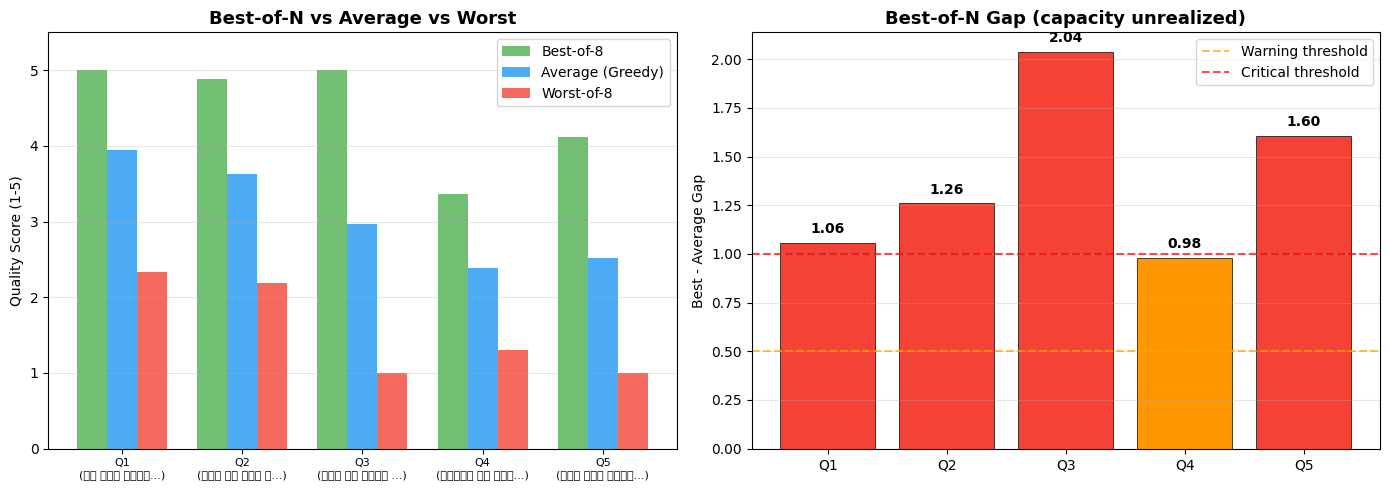

💡 해석:
  Gap < 0.5: 모델이 안정적 (Greedy ≈ Best)
  Gap 0.5-1.0: 개선 여지 있음 (더 나은 디코딩 전략 필요)
  Gap > 1.0: 모델이 '알지만 못 내놓는' 상태 (프롬프트/fine-tuning 필요)


In [6]:
# ============================================================
# Best-of-N 평가 시뮬레이션
# ============================================================

def simulate_model_responses(question: str, n: int = 5, quality_mean: float = 3.0,
                              quality_std: float = 1.0) -> List[Dict]:
    """매개변수에 \ub530\ub978 N\uac1c\uc758 \uc751\ub2f5\uc744 \uc2dc\ubbac\ub808\uc774\uc158 (\uc2e4\uc81c\ub85c\ub294 temperature\ub97c \ubc14\uafd4\uac00\uba70 generate)"""
    responses = []
    for i in range(n):
        quality = np.clip(np.random.normal(quality_mean, quality_std), 1, 5)
        responses.append({
            'response_id': i + 1,
            'text': f"Response #{i+1} (simulated, quality={quality:.1f})",
            'quality': round(quality, 2),
        })
    return responses


def best_of_n_analysis(questions: List[str], n_per_question: int = 5,
                        quality_means: List[float] = None) -> Dict:
    """Best-of-N \ubd84\uc11d"""
    if quality_means is None:
        quality_means = [3.0] * len(questions)
    
    results = {
        'questions': [],
        'greedy_avg': [],
        'best_of_n': [],
        'worst_of_n': [],
        'std_devs': [],
    }
    
    for q, qm in zip(questions, quality_means):
        responses = simulate_model_responses(q, n_per_question, qm, 1.0)
        qualities = [r['quality'] for r in responses]
        
        results['questions'].append(q[:40])
        results['greedy_avg'].append(np.mean(qualities))
        results['best_of_n'].append(max(qualities))
        results['worst_of_n'].append(min(qualities))
        results['std_devs'].append(np.std(qualities))
    
    return results


# 분석 실행
questions = [
    '직원 이름을 조회해줘',
    '부서별 평균 급여를 알려줘',
    '급여가 부서 평균보다 높은 직원을 찾아줘',
    '프로젝트별 참여 인원과 총 시간을 알려줘',
    '매니저 체인을 따라가서 보여줘',
]
quality_means = [4.2, 3.8, 3.0, 2.5, 2.0]  # Easy\u2192Hard

results = best_of_n_analysis(questions, n_per_question=8, quality_means=quality_means)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Best-of-N vs Greedy vs Worst
x = np.arange(len(questions))
width = 0.25

axes[0].bar(x - width, results['best_of_n'], width, label='Best-of-8', color='#4CAF50', alpha=0.8)
axes[0].bar(x, results['greedy_avg'], width, label='Average (Greedy)', color='#2196F3', alpha=0.8)
axes[0].bar(x + width, results['worst_of_n'], width, label='Worst-of-8', color='#F44336', alpha=0.8)

axes[0].set_ylabel('Quality Score (1-5)')
axes[0].set_title('Best-of-N vs Average vs Worst', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Q{i+1}\n({q[:12]}...)' for i, q in enumerate(questions)], fontsize=8)
axes[0].legend()
axes[0].set_ylim(0, 5.5)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: Gap analysis
gaps = [b - g for b, g in zip(results['best_of_n'], results['greedy_avg'])]
colors = ['#4CAF50' if g < 0.5 else '#FF9800' if g < 1.0 else '#F44336' for g in gaps]

bars = axes[1].bar(x, gaps, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Best - Average Gap')
axes[1].set_title('Best-of-N Gap (capacity unrealized)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Q{i+1}' for i in range(len(questions))])
axes[1].axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Warning threshold')
axes[1].axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Critical threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

for bar, gap in zip(bars, gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{gap:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("💡 해석:")
print("  Gap < 0.5: 모델이 안정적 (Greedy \u2248 Best)")
print("  Gap 0.5-1.0: 개선 여지 있음 (더 나은 디코딩 전략 필요)")  
print("  Gap > 1.0: 모델이 '\uc54c지만 \ubabb \ub0b4\ub193\ub294' \uc0c1\ud0dc (\ud504\ub86c\ud504\ud2b8/fine-tuning \ud544\uc694)")

## 5. Cohen's Kappa: 평가자 간 일치도

### 왜 필요한가?
- 평가자 A와 B가 70% 일치했다면, 이것이 의미 있는가?
- **문제**: 무작위로 선택해도 일정 비율 일치 (우연 일치)
- **Cohen's Kappa**: 우연 일치를 보정한 진짜 일치도

### 공식
$$\kappa = \frac{P_o - P_e}{1 - P_e}$$
- $P_o$: 실제 일치율 (observed agreement)
- $P_e$: 우연 일치율 (expected agreement)

### 해석 기준
| κ 값 | 해석 | 조치 |
|:----:|------|------|
| < 0.20 | Poor | 루브릭 재설계 필요 |
| 0.21-0.40 | Fair | 평가자 교육 필요 |
| 0.41-0.60 | Moderate | 수용 가능 |
| 0.61-0.80 | Substantial | 좋음 |
| 0.81-1.00 | Almost Perfect | 매우 좋음 |

📊 Cohen's Kappa 분석

🔍 Good rubric
   κ = 1.000 (Almost Perfect)
   Observed Agreement: 100.0%
   Expected (chance):  21.0%

🔍 Moderate rubric
   κ = 0.551 (Moderate)
   Observed Agreement: 65.0%
   Expected (chance):  22.0%

🔍 Poor rubric
   κ = -0.258 (Poor)
   Observed Agreement: 0.0%
   Expected (chance):  20.5%


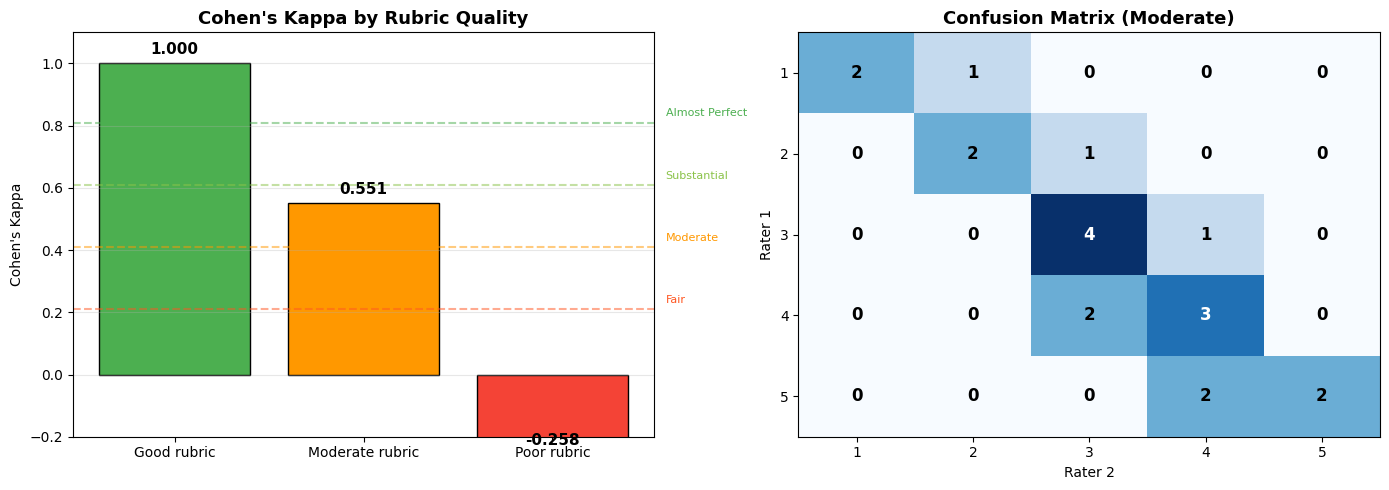


💡 루브릭이 명확할수록 κ가 높다
   κ < 0.4이면 루브릭 재설계가 필요하다


In [7]:
# ============================================================
# Cohen's Kappa 구현
# ============================================================

def cohens_kappa(rater1: List[int], rater2: List[int], categories: List[int] = None) -> Dict:
    """
    Cohen's Kappa \uacc4\uc0b0
    
    Args:
        rater1: \ud3c9\uac00\uc790 1\uc758 \uc810\uc218 \ub9ac\uc2a4\ud2b8
        rater2: \ud3c9\uac00\uc790 2\uc758 \uc810\uc218 \ub9ac\uc2a4\ud2b8
        categories: \uac00\ub2a5\ud55c \ubc94\uc8fc \ub9ac\uc2a4\ud2b8
    
    Returns:
        kappa, observed agreement, expected agreement
    """
    assert len(rater1) == len(rater2), "Both raters must evaluate the same number of items"
    
    if categories is None:
        categories = sorted(set(rater1 + rater2))
    
    n = len(rater1)
    
    # Observed agreement
    po = sum(1 for a, b in zip(rater1, rater2) if a == b) / n
    
    # Expected agreement
    pe = 0
    for cat in categories:
        p1 = sum(1 for x in rater1 if x == cat) / n
        p2 = sum(1 for x in rater2 if x == cat) / n
        pe += p1 * p2
    
    # Kappa
    if pe == 1:
        kappa = 1.0
    else:
        kappa = (po - pe) / (1 - pe)
    
    # Interpretation
    if kappa >= 0.81:
        interpretation = "Almost Perfect"
    elif kappa >= 0.61:
        interpretation = "Substantial"
    elif kappa >= 0.41:
        interpretation = "Moderate"
    elif kappa >= 0.21:
        interpretation = "Fair"
    else:
        interpretation = "Poor"
    
    return {
        'kappa': kappa,
        'observed_agreement': po,
        'expected_agreement': pe,
        'interpretation': interpretation,
        'n_items': n,
    }


# 시뮬레이션: 다양한 일치도 시나리오
scenarios = {
    'Good rubric': {
        'rater1': [5, 4, 3, 2, 1, 5, 4, 3, 2, 1, 4, 3, 5, 2, 3, 4, 5, 1, 3, 4],
        'rater2': [5, 4, 3, 2, 1, 5, 4, 3, 2, 1, 4, 3, 5, 2, 3, 4, 5, 1, 3, 4],
    },
    'Moderate rubric': {
        'rater1': [5, 4, 3, 2, 1, 5, 4, 3, 2, 1, 4, 3, 5, 2, 3, 4, 5, 1, 3, 4],
        'rater2': [5, 4, 3, 2, 2, 4, 4, 3, 3, 1, 3, 3, 5, 2, 3, 4, 4, 1, 4, 3],
    },
    'Poor rubric': {
        'rater1': [5, 4, 3, 2, 1, 5, 4, 3, 2, 1, 4, 3, 5, 2, 3, 4, 5, 1, 3, 4],
        'rater2': [3, 2, 5, 4, 3, 2, 1, 4, 5, 3, 2, 4, 3, 1, 5, 2, 3, 4, 1, 5],
    },
}

print("📊 Cohen's Kappa 분석")
print("=" * 60)

kappa_results = {}
for name, data in scenarios.items():
    result = cohens_kappa(data['rater1'], data['rater2'], categories=[1, 2, 3, 4, 5])
    kappa_results[name] = result
    print(f"\n🔍 {name}")
    print(f"   \u03ba = {result['kappa']:.3f} ({result['interpretation']})")
    print(f"   Observed Agreement: {result['observed_agreement']:.1%}")
    print(f"   Expected (chance):  {result['expected_agreement']:.1%}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Kappa comparison
names = list(kappa_results.keys())
kappas = [kappa_results[n]['kappa'] for n in names]
colors = ['#4CAF50' if k >= 0.61 else '#FF9800' if k >= 0.41 else '#F44336' for k in kappas]

bars = axes[0].bar(names, kappas, color=colors, edgecolor='black', linewidth=1)
axes[0].set_ylabel("Cohen's Kappa")
axes[0].set_title("Cohen's Kappa by Rubric Quality", fontsize=13, fontweight='bold')
axes[0].set_ylim(-0.2, 1.1)

# Reference lines
for threshold, label, color in [(0.81, 'Almost Perfect', '#4CAF50'), 
                                  (0.61, 'Substantial', '#8BC34A'),
                                  (0.41, 'Moderate', '#FF9800'),
                                  (0.21, 'Fair', '#FF5722')]:
    axes[0].axhline(y=threshold, color=color, linestyle='--', alpha=0.5)
    axes[0].text(2.6, threshold + 0.02, label, fontsize=8, color=color)

axes[0].grid(True, alpha=0.3, axis='y')

for bar, k in zip(bars, kappas):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{k:.3f}', ha='center', fontsize=11, fontweight='bold')

# Panel 2: Confusion matrix for "Moderate rubric"
from collections import Counter
mod_r1 = scenarios['Moderate rubric']['rater1']
mod_r2 = scenarios['Moderate rubric']['rater2']
confusion = np.zeros((5, 5), dtype=int)
for a, b in zip(mod_r1, mod_r2):
    confusion[a-1][b-1] += 1

im = axes[1].imshow(confusion, cmap='Blues', aspect='auto')
axes[1].set_xlabel('Rater 2')
axes[1].set_ylabel('Rater 1')
axes[1].set_title('Confusion Matrix (Moderate)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels([1, 2, 3, 4, 5])
axes[1].set_yticks(range(5))
axes[1].set_yticklabels([1, 2, 3, 4, 5])

for i in range(5):
    for j in range(5):
        color = 'white' if confusion[i][j] > 2 else 'black'
        axes[1].text(j, i, str(confusion[i][j]), ha='center', va='center', 
                    fontsize=12, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 루브릭이 명확할수록 \u03ba가 높다")
print("   \u03ba < 0.4이면 루브릭 재설계가 필요하다")

## 6. 3단계 평가 피라미드

### 실전 평가 전략
```
          /\
         /  \  Stage 3: Human Evaluation
        / 🧑 \  (50개, 높은 비용, 최종 판단)
       /------\
      /        \  Stage 2: Custom Eval Set
     / 📝 100개 \  (도메인 특화, 자동 실행)
    /------------\
   /              \  Stage 1: Benchmarks
  / 📊 MMLU, GSM8K \  (대규모, 저비용, 자동)
 /------------------\
```

### 각 단계의 역할
| 단계 | 규모 | 비용 | 목적 |
|------|------|------|------|
| Stage 1 | 수천 개 | 낮음 | 전반적 능력 체크 (regression 방지) |
| Stage 2 | 100-500개 | 중간 | 도메인 성능 확인 (핵심 지표) |
| Stage 3 | 30-50개 | 높음 | 미묘한 품질 차이 최종 판단 |

### 사용 시기
- **모든 실험**: Stage 1 (자동 벤치마크)
- **유망한 모델**: Stage 1 + Stage 2 (커스텀 평가)
- **최종 후보**: Stage 1 + Stage 2 + Stage 3 (Human Eval)

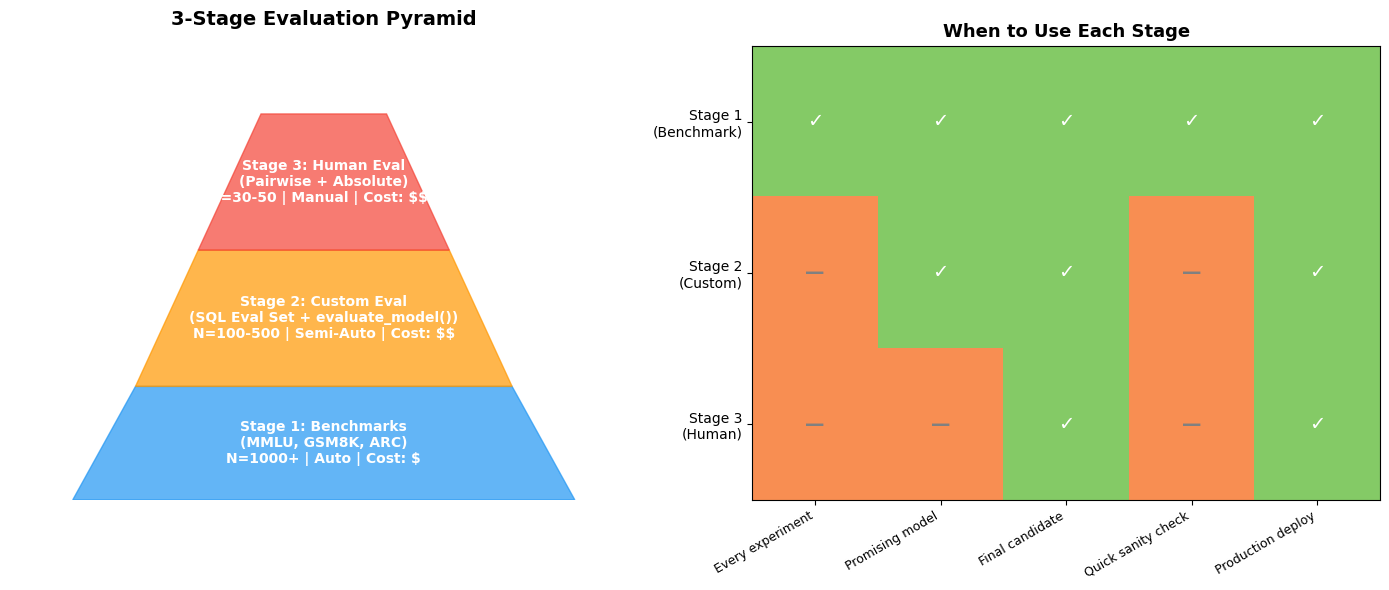

💡 실전 규칙:
  1. Stage 1은 CI/CD에 통합 (자동 실행)
  2. Stage 2는 주요 변경마다 실행
  3. Stage 3은 배포 직전에만 실행 (비용 절약)


In [9]:
# 3단계 평가 피라미드 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Pyramid
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Stage 1 (bottom)
ax.fill([1, 9, 8, 2], [0, 0, 2.5, 2.5], color='#2196F3', alpha=0.7)
ax.text(5, 1.25, 'Stage 1: Benchmarks\n(MMLU, GSM8K, ARC)\nN=1000+ | Auto | Cost: \$', 
        ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Stage 2 (middle)
ax.fill([2, 8, 7, 3], [2.5, 2.5, 5.5, 5.5], color='#FF9800', alpha=0.7)
ax.text(5, 4, 'Stage 2: Custom Eval\n(SQL Eval Set + evaluate_model())\nN=100-500 | Semi-Auto | Cost: \$\$', 
        ha='center', va='center', fontsize=10, fontweight='bold', color='white')

# Stage 3 (top)
ax.fill([3, 7, 6, 4], [5.5, 5.5, 8.5, 8.5], color='#F44336', alpha=0.7)
ax.text(5, 7, 'Stage 3: Human Eval\n(Pairwise + Absolute)\nN=30-50 | Manual | Cost: \$\$\$', 
        ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_title('3-Stage Evaluation Pyramid', fontsize=14, fontweight='bold', pad=15)

# Panel 2: When to use each stage
stages_data = {
    'Every experiment': [1, 0, 0],
    'Promising model': [1, 1, 0],
    'Final candidate': [1, 1, 1],
    'Quick sanity check': [1, 0, 0],
    'Production deploy': [1, 1, 1],
}

stage_names = list(stages_data.keys())
stage_matrix = np.array(list(stages_data.values()))

im = axes[1].imshow(stage_matrix.T, cmap='RdYlGn', aspect='auto', vmin=-0.5, vmax=1.5)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Stage 1\n(Benchmark)', 'Stage 2\n(Custom)', 'Stage 3\n(Human)'])
axes[1].set_xticks(range(len(stage_names)))
axes[1].set_xticklabels(stage_names, rotation=30, ha='right', fontsize=9)
axes[1].set_title('When to Use Each Stage', fontsize=13, fontweight='bold')

for i in range(3):
    for j in range(len(stage_names)):
        text = '\u2713' if stage_matrix[j][i] else '\u2014'
        color = 'white' if stage_matrix[j][i] else 'gray'
        axes[1].text(j, i, text, ha='center', va='center', fontsize=14, 
                    fontweight='bold', color=color)

plt.tight_layout()
plt.show()

print("💡 실전 규칙:")
print("  1. Stage 1은 CI/CD에 통합 (자동 실행)")
print("  2. Stage 2는 주요 변경마다 실행")
print("  3. Stage 3은 배포 직전에만 실행 (비용 절약)")

## 7. 핵심 정리

### 이번 노트북에서 배운 것
1. **자동 메트릭의 한계**: BLEU 0.9도 틀릴 수 있다
2. **Absolute Scoring**: 1-5 Likert + 명확한 루브릭이 핵심
3. **Pairwise Comparison**: Position Bias 교정을 위한 2회 교차 평가
4. **Best-of-N**: 모델의 상한 능력 vs 평균 능력 비교
5. **Cohen's Kappa**: 우연 일치 보정, κ > 0.6이면 수용 가능
6. **3단계 피라미드**: Benchmark → Custom → Human (비용 효율적)

### Phase 7 완성!
| 노트북 | 핵심 산출물 |
|--------|----------|
| 7-1 | 벤치마크 지도 + lm-eval + SQL 평가 함수 |
| 7-2 | 100개 평가셋 + evaluate_model() |
| 7-3 | Human Eval 프레임워크 + 평가 피라미드 |

> 💡 **핵심 원칙**: 모든 평가 메트릭은 사람의 판단을 근사하려는 시도다. 근사가 충분한지는, 결국 사람이 판단해야 한다.

In [10]:
# Phase 7 전체 체크포인트
checkpoint = {
    "phase": "7 (Complete)",
    "title": "LLM 평가 및 벤치마킹",
    "notebooks": {
        "7-1": "LLM 벤치마크와 자동 평가",
        "7-2": "커스텀 평가셋 구축",
        "7-3": "A/B 테스트와 Human Evaluation",
    },
    "key_outputs": [
        "✅ 8개 벤치마크 특성 + lm-eval 실행법",
        "✅ Text-to-SQL 100개 커스텀 평가셋",
        "✅ evaluate_model() 통합 평가 함수",
        "✅ Exact Match + Execution Accuracy",
        "✅ BLEU / ROUGE-L 직접 구현",
        "✅ LLM-as-Judge 프롬프트",
        "✅ Absolute Scoring + Pairwise + Best-of-N",
        "✅ Cohen's Kappa 평가자 일치도",
        "✅ 3단계 평가 피라미드",
    ],
    "next": "Phase 8: 추론 최적화 및 프로덕션 배포",
}

print("🏁 Phase 7 Complete!")
print("=" * 60)
print(f"📚 {checkpoint['title']}")
for nb_id, title in checkpoint['notebooks'].items():
    print(f"   [{nb_id}] {title}")

print(f"\n📋 Key Outputs:")
for item in checkpoint['key_outputs']:
    print(f"   {item}")

print(f"\n🔜 Next: {checkpoint['next']}")
print("\n💎 Phase 7 핵심: 평가 없는 파인튰닝은 눈 감고 운전하는 것이다.")

🏁 Phase 7 Complete!
📚 LLM 평가 및 벤치마킹
   [7-1] LLM 벤치마크와 자동 평가
   [7-2] 커스텀 평가셋 구축
   [7-3] A/B 테스트와 Human Evaluation

📋 Key Outputs:
   ✅ 8개 벤치마크 특성 + lm-eval 실행법
   ✅ Text-to-SQL 100개 커스텀 평가셋
   ✅ evaluate_model() 통합 평가 함수
   ✅ Exact Match + Execution Accuracy
   ✅ BLEU / ROUGE-L 직접 구현
   ✅ LLM-as-Judge 프롬프트
   ✅ Absolute Scoring + Pairwise + Best-of-N
   ✅ Cohen's Kappa 평가자 일치도
   ✅ 3단계 평가 피라미드

🔜 Next: Phase 8: 추론 최적화 및 프로덕션 배포

💎 Phase 7 핵심: 평가 없는 파인튰닝은 눈 감고 운전하는 것이다.
